In [7]:
# 의료 기초 데이터 분석 미니 프로젝트
# Numpy + Pandas + matplotlib

In [8]:
# ==============================
# [A] 라이브러리 import
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==============================
# [B] pandas 출력 옵션(선택)
# ==============================
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 200)


In [9]:
# ==============================
# # [1] 데이터 준비
# ==============================

data = {
    "측정일": [
        "2026-02-01","2026-02-01","2026-02-02","2026-02-02","2026-02-03",
        "2026-02-03","2026-02-04","2026-02-04","2026-02-05","2026-02-05",
        "2026-02-06","2026-02-06","2026-02-07","2026-02-07","2026-02-08"
    ],
    "환자ID": [
        "P001","P002","P003","P004","P005",
        "P006","P007","P008","P009","P010",
        "P011","P012","P013","P014","P015"
    ],
    "성별": ["F","M","M","F","F","M","M","F","F","M","F","M","M","F","F"],
    "나이":  [25, 31, 44, np.nan, 52, 39, 28, 33, 47, 61, 29, 42, np.nan, 36, 55],
    "키":    ["162cm","175cm","168cm","160cm","158cm","180cm","172cm","165cm","170cm","177cm","159cm","174cm","169cm","163cm","157cm"],
    "몸무게": ["54kg","78kg","70kg","52kg","60kg","90kg","68kg","58kg","73kg","82kg","50kg","76kg","71kg","57kg","66kg"],
    "SBP(수축기)": [108, 135, 142, 118, 150, 130, 125, 112, 140, 160, 105, 138, 145, 120, 155],
    "DBP(이완기)": [ 70,  88,  92,  75,  95,  85,  80,  72,  90, 100,  68,  89,  96,  78,  97],
    "심박수":      [72,  84,  90,  68,  95,  78,  70,  75,  88,  92,  66,  80,  86,  73,  89],
    "공복혈당":    [92,  110, 125,  98, 130, np.nan, 105,  90, 118, 140,  88, 112, 128, 100, np.nan],
    "흡연":        ["N","Y","Y","N","N","Y","N","N","Y","Y","N","Y","Y","N","N"],
    "운동빈도(주)": [3, 1, 0, 2, np.nan, 1, 4, 2, 1, 0, 5, 1, 0, 3, np.nan],
}

df = pd.DataFrame(data)
    

In [6]:
# ==============================
# [2] 데이터 탐색
# ==============================

print("==============================")
print("2) 데이터 탐색")
print("==============================")

print("\n[head()]")
print(df.head())

print("\n[info()] (데이터 구조 확인)")
print(df.info())

print("\n[describe()] (숫자 컬럼 요약)")
num_cols = ["나이", "SBP(수축기)", "DBP(이완기)", "심박수", "공복혈당", "운동빈도(주)"]
print(df[num_cols].describe())

2) 데이터 탐색

[head()]
          측정일  환자ID 성별    나이      키   몸무게  SBP(수축기)  DBP(이완기)  심박수   공복혈당 흡연  운동빈도(주)
0  2026-02-01  P001  F  25.0  162cm  54kg       108        70   72   92.0  N      3.0
1  2026-02-01  P002  M  31.0  175cm  78kg       135        88   84  110.0  Y      1.0
2  2026-02-02  P003  M  44.0  168cm  70kg       142        92   90  125.0  Y      0.0
3  2026-02-02  P004  F   NaN  160cm  52kg       118        75   68   98.0  N      2.0
4  2026-02-03  P005  F  52.0  158cm  60kg       150        95   95  130.0  N      NaN

[info()] (데이터 구조 확인)
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   측정일       15 non-null     str    
 1   환자ID      15 non-null     str    
 2   성별        15 non-null     str    
 3   나이        13 non-null     float64
 4   키         15 non-null     str    
 5   몸무게       15 non-null     str    
 6   SBP(수축기)  15 non-null     int64  

In [7]:
# ==============================
# [3] 데이터 정제 및 변환
# ==============================
print("==============================")
print("3) 데이터 정제 및 변환")
print("==============================")


# ---------------------------------------------
# 3-1) 타입 변환 : 날짜 문자열 -> datetime
# ---------------------------------------------
# pd.to_datetime(): 문자열을 날짜/시간 타입으로 변환
df["측정일"] = pd.to_datetime(df["측정일"])


# ---------------------------------------------
# 3-2) 단위 제거 : "170cm" -> 170, "65kg" -> 65
# ---------------------------------------------
# str.replace() : 문자열 치환(여기서는 단위 제거)
# astype(int) : 숫자형으로 변환
df["키_cm"] = df["키"].str.replace("cm", "", regex=False).astype(int)
df["몸무게_kg"] = df["몸무게"].str.replace("kg", "", regex=False).astype(int)

# 원본(키, 몸무게) 컬럼은 "문자열"이라 분석에 불리하므로
# 보통 숫자형 컬럼(키_cm, 몸무게_kg)만 쓰는 편


# ---------------------------------------------
# 3-3) 결측치 확인
# ---------------------------------------------
print("\n[결측치 개수 확인]")
print(df.isnull().sum())


# ---------------------------------------------
# 3-4) 결측치 처리(예시)
# ---------------------------------------------
'''
결측치 처리 방식은 정답이 1개가 아니라, 상황에 따라 다름
- 나이 : 평균으로 채울
- 공복혈당 : 중앙값으로 채울(극단값 영향을 줄이고 싶을 때)
- 운동빈도 : 0으로 채움(운동 기록이 없으면 0으로 가정하는 경우)
'''

df["나이"] = df["나이"].fillna(df["나이"].mean())
df["공복혈당"] = df["공복혈당"].fillna(df["공복혈당"].median()) # 중앙값
df["운동빈도(주)"] = df["운동빈도(주)"].fillna(0)


# ---------------------------------------------
# 3-5) 파생 컬럼 생성(변환)
# ---------------------------------------------
# BMI = 몸무게(kg) / (키(m)^2)
df["키_m"] = df["키_cm"] / 100
df["BMI"] = df["몸무게_kg"] / (df["키_m"] ** 2)

# 맥박압(PP) = SBP - DBP (혈관 탄성/압력 차이를 보는 간단 지표)
df["맥박압_PP"] = df["SBP(수축기)"] - df["DBP(이완기)"]

# 평균동맥압("MAP") = (SBP + 2*DBP) / 3 (기초적인 참고 지표)
df["평균동맥압_MAP"] = (df["SBP(수축기)"] + 2 * df["DBP(이완기)"]) / 3


# ---------------------------------------------
# 3-6) 범주화(카테고리 만들기) : 혈압 단계 분류
# ---------------------------------------------
'''
기준(간단 버전)
- 정상 : SBP < 120 그리고 DBP < 80
- 주의(상승) : SBP 120~129 그리고 DBP < 80
- 고혈압1기 : SBP 130~139 또는 DBP 80~89
- 고혈압2기 : SBP >= 140 또는 DBP >= 80
'''

def bp_category(sbp, dbp):
    if (sbp < 120) and (dbp < 80):
        return "정상"
    elif (120 <= sbp <= 129) and (dbp < 80):
        return "주의(상승)"
    elif (130 <= sbp <= 139) or (80 <= dbp <= 89):
        return "고혈압1기"
    elif (sbp >= 140) or (dbp >= 90):
        return "고혈압2기"
    else:
        return "기타"
    
# apply() : 행 단위로 함수를 적용할 때 자주 사용
# lambda row : 익명 함수(이름 없는 함수)
# lambda 입력값 : 계산식
df["혈압분류"] = df.apply(lambda row: bp_category(row["SBP(수축기)"], row["DBP(이완기)"]), axis=1)



# ---------------------------------------------
# 3-7) 범주화 : BMI 단계 분류(간단 예시)
# ---------------------------------------------
'''
BMI 분류
- 저체중 : < 18.5
- 정상 : 18.5 ~ 22.9
- 과체중 : 23.0 ~ 24.9
- 비만 : >= 25.0
'''

def bmi_category(bmi):
    if bmi < 18.5:
        return "저체중"
    elif bmi < 23.0:
        return "정상"
    elif bmi < 25.0:
        return "과체중"
    else:
        return "비만"

df["BMI분류"] = df["BMI"].apply(bmi_category)

print("\n[정제/변환 결과 미리보기]")
show_cols = ["측정일","환자ID","성별","나이","키_cm","몸무게_kg","SBP(수축기)","DBP(이완기)","공복혈당","운동빈도(주)","BMI","혈압분류","BMI분류"]
print(df[show_cols].head(10))# ==============================
# [3] 데이터 정제 및 변환
# ==============================
print("==============================")
print("3) 데이터 정제 및 변환")
print("==============================")


# ---------------------------------------------
# 3-1) 타입 변환 : 날짜 문자열 -> datetime
# ---------------------------------------------
# pd.to_datetime(): 문자열을 날짜/시간 타입으로 변환
df["측정일"] = pd.to_datetime(df["측정일"])


# ---------------------------------------------
# 3-2) 단위 제거 : "170cm" -> 170, "65kg" -> 65
# ---------------------------------------------
# str.replace() : 문자열 치환(여기서는 단위 제거)
# astype(int) : 숫자형으로 변환
df["키_cm"] = df["키"].str.replace("cm", "", regex=False).astype(int)
df["몸무게_kg"] = df["몸무게"].str.replace("kg", "", regex=False).astype(int)

# 원본(키, 몸무게) 컬럼은 "문자열"이라 분석에 불리하므로
# 보통 숫자형 컬럼(키_cm, 몸무게_kg)만 쓰는 편


# ---------------------------------------------
# 3-3) 결측치 확인
# ---------------------------------------------
print("\n[결측치 개수 확인]")
print(df.isnull().sum())


# ---------------------------------------------
# 3-4) 결측치 처리(예시)
# ---------------------------------------------
'''
결측치 처리 방식은 정답이 1개가 아니라, 상황에 따라 다름
- 나이 : 평균으로 채울
- 공복혈당 : 중앙값으로 채울(극단값 영향을 줄이고 싶을 때)
- 운동빈도 : 0으로 채움(운동 기록이 없으면 0으로 가정하는 경우)
'''

df["나이"] = df["나이"].fillna(df["나이"].mean())
df["공복혈당"] = df["공복혈당"].fillna(df["공복혈당"].median()) # 중앙값
df["운동빈도(주)"] = df["운동빈도(주)"].fillna(0)


# ---------------------------------------------
# 3-5) 파생 컬럼 생성(변환)
# ---------------------------------------------
# BMI = 몸무게(kg) / (키(m)^2)
df["키_m"] = df["키_cm"] / 100
df["BMI"] = df["몸무게_kg"] / (df["키_m"] ** 2)

# 맥박압(PP) = SBP - DBP (혈관 탄성/압력 차이를 보는 간단 지표)
df["맥박압_PP"] = df["SBP(수축기)"] - df["DBP(이완기)"]

# 평균동맥압("MAP") = (SBP + 2*DBP) / 3 (기초적인 참고 지표)
df["평균동맥압_MAP"] = (df["SBP(수축기)"] + 2 * df["DBP(이완기)"]) / 3


# ---------------------------------------------
# 3-6) 범주화(카테고리 만들기) : 혈압 단계 분류
# ---------------------------------------------
'''
기준(간단 버전)
- 정상 : SBP < 120 그리고 DBP < 80
- 주의(상승) : SBP 120~129 그리고 DBP < 80
- 고혈압1기 : SBP 130~139 또는 DBP 80~89
- 고혈압2기 : SBP >= 140 또는 DBP >= 80
'''

def bp_category(sbp, dbp):
    if (sbp < 120) and (dbp < 80):
        return "정상"
    elif (120 <= sbp <= 129) and (dbp < 80):
        return "주의(상승)"
    elif (130 <= sbp <= 139) or (80 <= dbp <= 89):
        return "고혈압1기"
    elif (sbp >= 140) or (dbp >= 90):
        return "고혈압2기"
    else:
        return "기타"
    
# apply() : 행 단위로 함수를 적용할 때 자주 사용
# lambda row : 익명 함수(이름 없는 함수)
# lambda 입력값 : 계산식
df["혈압분류"] = df.apply(lambda row: bp_category(row["SBP(수축기)"], row["DBP(이완기)"]), axis=1)



# ---------------------------------------------
# 3-7) 범주화 : BMI 단계 분류(간단 예시)
# ---------------------------------------------
'''
BMI 분류
- 저체중 : < 18.5
- 정상 : 18.5 ~ 22.9
- 과체중 : 23.0 ~ 24.9
- 비만 : >= 25.0
'''

def bmi_category(bmi):
    if bmi < 18.5:
        return "저체중"
    elif bmi < 23.0:
        return "정상"
    elif bmi < 25.0:
        return "과체중"
    else:
        return "비만"

df["BMI분류"] = df["BMI"].apply(bmi_category)

print("\n[정제/변환 결과 미리보기]")
show_cols = ["측정일","환자ID","성별","나이","키_cm","몸무게_kg","SBP(수축기)","DBP(이완기)","공복혈당","운동빈도(주)","BMI","혈압분류","BMI분류"]
print(df[show_cols].head(10))

3) 데이터 정제 및 변환

[결측치 개수 확인]
측정일         0
환자ID        0
성별          0
나이          2
키           0
몸무게         0
SBP(수축기)    0
DBP(이완기)    0
심박수         0
공복혈당        2
흡연          0
운동빈도(주)     2
키_cm        0
몸무게_kg      0
dtype: int64

[정제/변환 결과 미리보기]
         측정일  환자ID 성별         나이  키_cm  몸무게_kg  SBP(수축기)  DBP(이완기)   공복혈당  운동빈도(주)        BMI   혈압분류 BMI분류
0 2026-02-01  P001  F  25.000000   162      54       108        70   92.0      3.0  20.576132     정상    정상
1 2026-02-01  P002  M  31.000000   175      78       135        88  110.0      1.0  25.469388  고혈압1기    비만
2 2026-02-02  P003  M  44.000000   168      70       142        92  125.0      0.0  24.801587  고혈압2기   과체중
3 2026-02-02  P004  F  40.153846   160      52       118        75   98.0      2.0  20.312500     정상    정상
4 2026-02-03  P005  F  52.000000   158      60       150        95  130.0      0.0  24.034610  고혈압2기   과체중
5 2026-02-03  P006  M  39.000000   180      90       130        85  110.0      1.0  27.777778  고혈압1기    

In [ ]:
# ==============================
# [4] 분석
# ==============================
print("==============================")
print("4) 분석")
print("==============================")


# ---------------------------------------------
# 4-1) 최고/최저 : BMI가 가장 높은/낮은 사람
# ---------------------------------------------
max_bmi_row = df.loc[df["BMI"].idxmax()] # 최댓값 위치 반환
min_bmi_row = df.loc[df["BMI"].idxmin()] # 최솟값 위치 반환

print("\n[BMI 최고]")
print(max_bmi_row[["환자ID", "성별", "나이", "키_cm", "몸무게_kg", "BMI", "BMI분류"]])
print("\n[BMI 최저]")
print(min_bmi_row[["환자ID", "성별", "나이", "키_cm", "몸무게_kg", "BMI", "BMI분류"]])


# ---------------------------------------------
# 4-2) 혈압 분류별 평균 지표
# ---------------------------------------------
bp_group = df.groupby("혈압분류")[["SBP(수축기)", "DBP(이완기)", "맥박압_PP", "평균동맥압_MAP", "BMI", "공복혈당"]].mean().sort_values("SBP(수축기)", ascending=False)

print("\n[혈압분류별 평균]")
print(bp_group)


# ---------------------------------------------
# 4-3) 성별 평균 비교
# ---------------------------------------------
gender_mean = df.groupby("성별")[["SBP(수축기)", "DBP(이완기)", "심박수", "공복혈당", "BMI", "운동빈도(주)"]].mean()

print("\n[성별 평균 비교]")
print(gender_mean)


# ---------------------------------------------
# 4-4) 나이대(연령대) 만들기 + 그룹 평균
# ---------------------------------------------
'''
나이대는 분석에서 자주 사용
- pd.cut() : 숫자를 구간으로 나눠 범주형 컬럼 생성
'''

bins = [0, 29, 39, 49, 59, 120]
labels = ["20대", "30대", "40대", "50대", "60대 이상"]
df["나이대"] = pd.cut(df["나이"], bins=bins, labels=labels, right=True)

age_group = df.groupby("나이대")[["SBP(수축기)", "DBP(이완기)", "공복혈당", "BMI"]].mean()
print("\n[나이대별 평균]")
print(age_group)

# ---------------------------------------------
# 4-5) 상관관계(수치형 컬럼)
# ---------------------------------------------
'''
corr(): 상관계수(-1 ~ 1)
- 1에 가까울수록 같이 오르는 경향(양의 상관)
- -1에 가까울수록 반대로 움직이는 경향(음의 상관)
- 0에 가까우면 관계가 거의 없음(무상관에 가까움)
'''
corr_cols = ["나이", "키_cm", "몸무게_kg", "SBP(수축기)", "DBP(이완기)", "심박수", "공복혈당", "운동빈도(주)", "BMI", "맥박압_PP", "평균동맥압_MAP"]
corr_df = df[corr_cols].corr()

print("\n[상관관계]")
print(corr_df)


# ---------------------------------------------
# 4-6) 조건 필터링
# ---------------------------------------------
'''
예시 위험군 조건:
- 혈압 : 고혈압2기
- 공복혈당 : 126 이상(당뇨 기준으로 자주 언급되는 구간)
- BMI : 25 이상(비만)

해당 조건 중 하나라도 True면 관심 대상이라고 가정
'''

risk_df = df[
    (df["혈압분류"] == "고혈압2기") |
    (df["공복혈당"] >= 126) |
    (df["BMI"] >= 25.0)
].copy()

print("\n[관심 대상 목록]")
print(risk_df[["환자ID", "성별", "나이", "SBP(수축기)", "DBP(이완기)", "혈압분류", "공복혈당", "BMI", "BMI분류", "운동빈도(주)"]])



4) 분석

[BMI 최고]
환자ID           P006
성별                M
나이             39.0
키_cm            180
몸무게_kg           90
BMI       27.777778
BMI분류            비만
Name: 5, dtype: object

[BMI 최저]
환자ID           P011
성별                F
나이             29.0
키_cm            159
몸무게_kg           50
BMI       19.777699
BMI분류            정상
Name: 10, dtype: object

[혈압분류별 평균]
          SBP(수축기)  DBP(이완기)     맥박압_PP   평균동맥압_MAP        BMI        공복혈당
혈압분류                                                                      
고혈압2기   148.666667     95.00  53.666667  112.888889  25.317425  125.166667
고혈압1기   132.000000     85.50  46.500000  101.000000  25.333739  109.250000
주의(상승)  120.000000     78.00  42.000000   92.000000  21.453574  100.000000
정상      110.750000     71.25  39.500000   84.416667  20.492570   92.000000

[성별 평균 비교]
      SBP(수축기)  DBP(이완기)        심박수        공복혈당        BMI  운동빈도(주)
성별                                                                 
F   126.000000    80.625  78.250000  

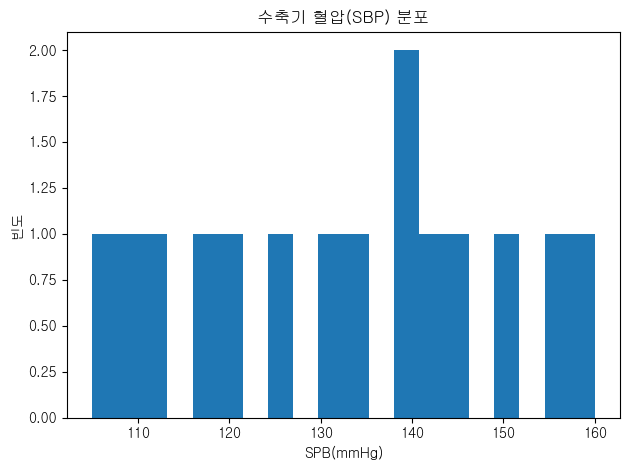

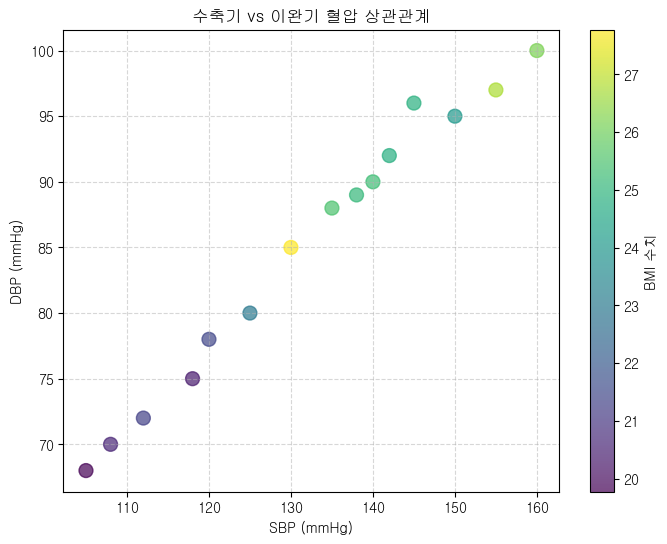

In [ ]:
import matplotlib
import matplotlib.font_manager as fm

# 원하는 폰트 파일 경로 문자열로 입력
font_location = "C:\\Windows\\Fonts\\gulim.ttc"

# 지정한 폰트 파일 경로에서 폰트 추출
fontname = fm.FontProperties(fname=font_location).get_name()

# matplotlib의 전역 폰트 설정 변경
matplotlib.rc('font', family=fontname)

# ==============================
# [5] 시각화
# ==============================
print("==============================")
print("5) 시각화")
print("==============================")


# ---------------------------------------------
# 5-1) 혈압(SBP/DBP) 분포 히스토그램
# ---------------------------------------------
'''
히스토그램
- 숫자 데이터가 어느 구간에 얼마나 많이 모여 있는지 보여주는 그래프
- bins가 크면 클 수록 나뉘는 구간이 촘촘함
- 구간 수에 따라 그래프 모양이 달라짐
'''
plt.figure() # 그래프 공간 생성
plt.hist(df["SBP(수축기)"], bins=8) # 구간 설정
plt.title("수축기 혈압(SBP) 분포") # 그래프 위 제목
plt.xlabel("SBP(mmHg)") # 가로축 의미 설명
plt.ylabel("빈도") # 세로축 의미 설명
plt.tight_layout() # 글자가 잘리지 않게 자동 정렬
plt.show() # 그래프 출력

plt.figure()
plt.hist(df["DBP(이완기)"], bins=8)
plt.title("이완기 혈압(SBP) 분포")
plt.xlabel("DBP(mmHg)")
plt.ylabel("빈도")
plt.tight_layout()
plt.show()


# ---------------------------------------------
# 5-2) 혈압분류별 평균 SBP 막대그래프
# ---------------------------------------------
bp_sbp_mean = df.groupby("혈압분류")["SBP(수축기)"].mean().sort_values(ascending=False)

plt.figure()
plt.bar(bp_sbp_mean.index, bp_sbp_mean.values)
plt.title("혈압분류별 평균 SBP")
plt.xlabel("혈압분류")
plt.ylabel("평균 SBP(mmHg)")
plt.tight_layout()
plt.show()


# ---------------------------------------------
# 5-3) BMI 분포 히스토그램
# ---------------------------------------------
plt.figure()
plt.hist(df["BMI"], bins=8)
plt.title("BMI 분포")
plt.xlabel("BMI")
plt.ylabel("빈도")
plt.tight_layout()
plt.show()


# ---------------------------------------------
# 5-4) 산점도 : BMI vs SBP
# ---------------------------------------------
'''
산점도 : 두 개의 숫자 변수 관계를 점(dot)으로 표현 그래프
'''
plt.figure()
plt.scatter(df["BMI"], df["SBP(수축기)"])
plt.title("BMI와 SBP 관계(산점도)")
plt.xlabel("BMI")
plt.ylabel("SBP(mmHg)")
plt.tight_layout()
plt.show()


# ---------------------------------------------
# 5-5) 측정일 기준 SBP 추이(날짜별 평균)
# ---------------------------------------------
date_sbp = df.groupby("측정일")["SBP(수축기)"].mean()

plt.figure()
plt.plot(date_sbp.index, date_sbp.values)
plt.title("측정일별 평균 SBP 추이")
plt.xlabel("측정일")
plt.ylabel("평균 SBP(mmHg)")
plt.xticks(rotation=30) # x축 눈금(ticks) : 글자가 길 때
plt.tight_layout()
plt.show()

In [ ]:
# ==============================
# [6] 인사이트 자동 생성
# ==============================
print("==============================")
print("6) 인사이트(자동 요약)")
print("==============================")


# ---------------------------------------------
# 6-1) 혈압분류 비율
# ---------------------------------------------
bp_counts = df["혈압분류"].value_counts() # 혈압분류 개수 세기
bp_ratio = (bp_counts / len(df)) * 100 # 비율 계산

print("\n[혈압분류 분포(개수)]")
print(bp_counts)

print("\n[혈압분류 분포(비율%)]")
print(bp_ratio.round(1)) # 소수점 한 자리까지만 표시


# ---------------------------------------------
# 6-2) 위험 신호 : 공복혈당 평균과 126 이상 비율
# ---------------------------------------------
mean_glu = df["공복혈당"].mean()
high_glu_ratio = (df["공복혈당"] >= 126).mean() * 100 # True=1, False=0이므로 평균=비율

print(f"\n[공복혈당 평균] {mean_glu:.2f} mg/dL")
print(f"[공복혈당 126 이상 비율] {high_glu_ratio:.1f}%")


# ---------------------------------------------
# 6-3) 운동빈도와 주요 지표 관계
# ---------------------------------------------
# 상관계수만으로 원인/결론을 단정하면 안 되지만, 흐름을 보는 연습에는 좋음
corr_exercise_sbp = df["운동빈도(주)"].corr(df["SBP(수축기)"])
corr_exercise_bmi = df["운동빈도(주)"].corr(df["BMI"])

print(f"\n[운동빈도 vs SBP 상관계수] {corr_exercise_sbp:.2f}")
print(f"[운동빈도 vs BMI 상관계수] {corr_exercise_bmi:.2f}")


# ---------------------------------------------
# 6-4) 전략/제안 3줄
# ---------------------------------------------
strategy = []

# 혈압2기 비율 기반 코멘트
ht2_ratio = (df["혈압분류"] == "고혈압2기").mean() * 100

if ht2_ratio >= 30:
    strategy.append("고혈압2기 비율이 높은 편이라, 생활습관(운동/체중/염분)관련 교육 및 추적 관리가 필요합니다.")
else:
    strategy.append("고혈압2기 비율이 과도하게 높진 않지만, 고혈압1기 이상에 대한 예방 안내가 유효합니다.")

# BMI 비만 비율 코멘트
obesity_ratio = (df["BMI분류"] == "비만").mean() * 100
strategy.append(f"BMI 기준 비만 비율이 {obesity_ratio:.1f}%로 확인되어, 체중 관리(식습관+운동) 프로그램을 고려할 수 있습니다.")

# 혈당 고위험 비율 코멘트
if high_glu_ratio > 20:
    strategy.append("공복혈당 126 이상 비율이 꽤 있어, 혈단 관련 추가 검사/상담 연계를 고려할 수 있습니다.")
else:
    strategy.append("공복혈당 고위험 비율이 높진 않지만, 식습관/활동량 관련 기본 가이드를 제공하면 좋습니다.")

print("\n[제안 3줄]")
for s in strategy:
    print(f"- {s}")

6) 인사이트(자동 요약)

[혈압분류 분포(개수)]
혈압분류
고혈압2기     6
정상        4
고혈압1기     4
주의(상승)    1
Name: count, dtype: int64

[혈압분류 분포(비율%)]
혈압분류
고혈압2기     40.0
정상        26.7
고혈압1기     26.7
주의(상승)     6.7
Name: count, dtype: float64

[공복혈당 평균] 110.40 mg/dL
[공복혈당 126 이상 비율] 20.0%

[운동빈도 vs SBP 상관계수] -0.86
[운동빈도 vs BMI 상관계수] -0.76

       [ 종합 건강검진 분석 결과 ]
▶ 맞춤 전략: 고혈압관리
----------------------------------------
※ 분석 근거: 고혈압 2기 비율 40.0%


In [10]:
# ==============================
# [7] 저장
# ==============================
print("==============================")
print("7) 저장")
print("==============================")


output_path = "medical_basic_analysis_result.csv"

# to_csv() 저장
# - index=False: 행 인덱스(0, 1, 2...)를 파일에 저장하지 않음
# - encoding="utf-8-sig" : 엑셀에서 한글 깨짐 방지(윈도우 환경에서 유용)
df.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"저장 완료 : {output_path}")
print("\n프로젝트 종료!")

7) 저장
저장 완료 : medical_basic_analysis_result.csv

프로젝트 종료!
